# 📝 Práctica M10: Estimación de Precios de Mercado de Portátiles

En este ejercicio, actuarás como un analista de datos para una tienda de tecnología. Tu objetivo es construir un modelo que estime el precio de mercado de un portátil basándose en sus componentes.

Los datos pueden encontrarse en:
https://www.kaggle.com/datasets/waddahali/laptop-prices-and-specifications-dataset

## El Contexto de Negocio

Imagina que una empresa de re-commerce (reventa de tecnología) quiere expandirse al mercado de Oriente Medio, concretamente a Egipto. Te han entregado un archivo "bruto" extraído mediante web scraping en noviembre de 2025. Su objetivo es claro: necesitan un tasador automático. Quieren saber si, basándose en las especificaciones técnicas, podemos predecir el precio de mercado con un margen de error menor al 5%.

## El Desafío de la industria
Este dataset no es el típico archivo limpio de Kaggle. Como ocurre en las empresas de verdad, los datos están "sucios". Tu trabajo no empieza entrenando el modelo; empieza en el barro:

1. Inspección y Rescate: ¿Ese nulo es un error o es un cero? (Recuerda la lógica que vimos en el Módulo 2).

2. Estandarización: Los textos vienen de plataformas de e-commerce distintas. Tendrás que unificar formatos de CPUs, GPUs y marcas.

3. Ingeniería de Características: ¿Cómo influye la generación de un procesador en el precio final? ¿Es más relevante la RAM o el tipo de almacenamiento?

4. Cambio de Divisa: Los precios están en Libras Egipcias (EGP). Como analista, deberás decidir si trabajas con la moneda local o aplicas una tasa de cambio para facilitar la interpretación de negocio.

## El camino
No busques el algoritmo más complejo. Busca el modelo más sólido.

Hito 1: Limpiar y transformar el dataset hasta que sea apto para una máquina.

Hito 2: Construir los modelo de regresión que hemos aprendido y seleccionar el que mejor entienda el valor del hardware y obtenga mejores predicciones.

Hito 3: Validar si somos capaces de predecir el precio con esa precisión del 5% que nos pide el cliente.

## El Objetivo: La Búsqueda del "Mejor" Modelo

Tu misión final no es entregar un archivo .ipynb con una regresión lineal y ya está. Tu objetivo es construir un Banco de Pruebas (Benchmark) donde sometas a competición a todos los "contendientes" que hemos visto en el curso:

- Regresión Lineal: Tu línea base (Baseline). Es sencilla e interpretable, pero ¿es suficiente para capturar la complejidad del mercado?

- Random Forest / XGBoost: Los reyes del dato tabular. ¿Son capaces de manejar las relaciones no lineales entre la RAM, el procesador y el precio sin sobreajustar (overfitting)?

Para decidir cuál es el ganador, no te fijarás solo en un número. Deberás realizar un testeo cruzado basado en tres pilares:

1. **Precisión Métrica**: Deberás presentar una tabla comparativa final con los resultados de cada modelo sobre el set de Test (datos que el modelo nunca ha visto):

    - MAE (Mean Absolute Error): ¿Cuántos euros se desvía el modelo en promedio?

    - R² (R-Cuadrado): ¿Qué porcentaje de la variabilidad del precio estamos explicando realmente?

2. **Análisis de Residuos**: Un modelo puede tener un MAE bajo pero fallar estrepitosamente en los portátiles de gama alta. ¿El modelo infravalora sistemáticamente los ordenadores de lujo? ¿Hay algún sesgo en marcas específicas?

3. **Interpretabilidad vs. Performance**: A veces, un modelo que falla por 5€ más que otro es mejor porque nos permite explicarle al departamento de compras por qué el precio es ese (usando los coeficientes o valores SHAP). Deberás justificar tu elección final basándote en este equilibrio.

## Instrucciones para la Entrega Final
Tu notebook debe concluir con una Sección de Juicio Crítico:

- Tabla de Benchmark: Comparativa visual de las métricas de todos los modelos testeados.

- Justificación de Selección: Un texto breve donde digas: "Elijo el modelo [X] porque, aunque su R² es similar al de [Y], presenta una mayor estabilidad en los residuos y una menor complejidad computacional".

- Predicción en Producción: Ejecuta tu modelo ganador con unos datos de test para demostrar que está listo para su uso real.

## Consejos y consideraciones

1. Elimina las variables ``['Keyboard', 'Battery', 'Connections', 'Dimensions', 'Colors', 'Product name', 'Processor Details', 'Product number', 'Power supply type', 'Laptop Color', 'SUPPORT SSD M2', 'Pointing device', 'Optical drive', 'Series :']`` ya que tienen más ruido que otra cosa (puedes comprobarlo por ti mism@ antes de hacerlo).

2. Puedes limpiar la variable ``RAM`` utilzando el siguiente código: 
``df['RAM_GB'] = df['RAM'].str.extract(r'(\d+)').astype(float)``

3. A partir del código previo, puedes limpiar el resto de variables "sucias" por contener las unidades

4. Normaliza la variable ``Hard drive`` ya que tiene medidas en TB, GB, etc.

5. Crea una variable ``Processor`` a partir de la ``CPU_Class`` según contenga un 9,7,5 o 3 (gama del procesador).

6. Si quieres transformar el precio a euros, la equivalencia es **0.018**

7. Considera un dataset de **test con el 30%** de tu dataset. 

## Mucha suerte!

Hasta aquí llegan todas las notas que te daré para ayudarte. 

Debajo tienes el notebook con la forma en la que resolvería yo este problema. Intenta resolverlo de forma autónoma y solo revisa como lo haría yo una vez hayas terminado tus modelos. Puedes hacer una segunda iteración mezclando lo que he hecho yo y las ideas que has tenido tú. 

Como nota, el mejor modelo que he obtenido tiene las siguientes métricas, espero que puedas superarlas!

- MAE (Error Medio Absoluto): 175.30764325647544

- MSE (Error Cuadrático Medio): 80123.83861363136

- RMSE (Raíz del Error Cuadrático Medio): 283.0615456285635

- R2 Score (Varianza explicada): 0.7300269878453158

________________________________________

# Carga de los datos

Lo primero siempre es cargar nuestros datos y entender el problema al que nos enfrentamos.

Los datos pueden descargarse y consultarse aquí: https://www.kaggle.com/datasets/waddahali/laptop-prices-and-specifications-dataset

En la página podemos ver una descripción del problema, de las variables y de todo lo que necesitamos saber.

In [294]:
# Cargamos las librerias que vamos a utilizar
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df = pd.read_csv('../Data/laptops_Dataset.csv') 

In [296]:
# Con la opcion que indicamos en set_option nos muestra todas las columnas (por defecto corta las columnas si son muchas)
pd.set_option('display.max_columns', None)
df.head()

,Brand:,Product name,Processor,Video graphics,Video graphics Memorey,RAM,Hard drive,Display,Display Resolution,Display Refresh Rate,Operating System,Keyboard,Battery,Webcam,Connections,Dimensions,Weight,Colors,Warranty,Price,Processor Generation,Processor Details,Product number,Power supply type,Laptop Color,Finger Print,SUPPORT SSD M2,Pointing device,Optical drive,Series :
0,MSI,Titan 18 HX Dragon Edition Norse Myth A2XWJG,Intel Core Ultra 9 285HX,Nvidia GeForce RTX 5090 24GB,24GB GDDR7,96GB DDR5 6400MHz 48GB*2,"6TB, 2TB NVMe PCIe Gen5x4 SSD w/o DRAM + 2TB N...","18"" 16:10 UHD+ (3840x2400), MiniLED, 120Hz, 10...",3840x2400,120 Hz,Windows® 11 Home,Cherry Mechanical Per-Key RGB Gaming Keyboard ...,4-Cell 99 Battery (Whr),IR FHD type (30fps@1080p) with HDR 3D Noise Re...,2x Thunderbolt™ 5 (DisplayPort™/ Power Deliver...,404 x 307.5 x 24-32.05 mm,3.6 kg,Core Black,2 Year,320000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MSI,Katana 15 HX 14XWGK,Intel Core i9-14900HX,Nvidia GeForce RTX 5070 8GB,8GB GDDR7,16GB DDR5 8GB*2,1TB NVMe PCIe SSD Gen4x4,"15.6"" QHD (2560*1440), 165Hz DCI-P3 100% typical",2560*1440,165 HZ,Windows® 11 Home,4-Zone RGB Gaming Keyboard,"4 cell, 75Whr",HD Webcam (720p @ 30fps),1x USB Type-C (USB 3.2 Gen2 / DisplayPort / Po...,359 x 262 x 25.5 mm,2.4 kg,Black,2 Year,79999,14th generation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Acer,NITRO V15-ANV15-51-51H9,Intel Core I5-13420H,Nvidia GeForce RTX 4050 6GB,6GB GDDR6,8 GB DDR5-SDRAM,512 GB SSD,15.6'' Inch FHD IPS LED backlight aspect ratio...,1920x1080,144 Hz,Windows® 11 Home,NaN,57 Wh,NaN,USB 3.2 Gen 1 (3.1 Gen 1) Type-A ports quantit...,NaN,NaN,Black,1 Year,39999,13th generation,"8C (4P + 4E) / 12T, P-core 2.1 / 4.6GHz, E-cor...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Dell,Alienware 16 Aurora AC16250,Intel Core 7 240H,NVIDIA(R) GeForce RTX(TM) 5050,8 GB GDDR7,"16GB, 2x8GB, DDR5, 5600 MT/s ( 5200 MT/s with ...",512GB M.2 PCIe NVMe SSD,"16"" WQXGA 120Hz, 300 nits, ComfortView Plus, 1...",2560 x 1600,120 Hz,Windows 11 Home,NaN,"6-Cell Battery, 96 Whr (Integr ated)",NaN,2 USB 3.2 Gen 1 (5 Gbps) ports 1 USB 3.2 Gen 2...,356.98 x 265.43 x 15.20 mm,2.49 kg,NaN,1 Year,57999,NaN,"240H (24MB cache, 1 0 cores, 1.80 to 5.20 GHz ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Dell,Alienware 16 Aurora AC16250,Intel Core 9 270H,Nvidia GeForce RTX 5060 8GB,8GB GDDR7,"16GB, 2x8GB, DDR5, 5600 MT/s",1TB M.2 PCIe NVMe SSD,"16"" WQXGA 120Hz, 300 nits, ComfortView Plus, 1...",2560 x 1600,120 Hz,DOS,Alienware White Backlit Keyboard,"6-Cell Battery, 96 Whr (Integrated)","720p at 30 fps HD camera, Dual-array microphones",2 USB Type-A 3.2 Gen 1 Port 1 Type-C® Port (US...,356.98 x 265.43 x 22.70 mm,2.49 kg,NaN,1 Year,89999,NaN,"24MB cache, 14 cores, 2.00 to 5.80 GHz P-Core",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Limpieza e Ingeniería de Datos

Vamos a realizar un proceso de Data Wrangling para transformar las especificaciones técnicas (que vienen en formato texto) en variables numéricas que nuestros modelos puedan entender.

Cambia el nombre de la variable ``Brand:`` eliminando los ":". 

In [297]:
df = df.rename(columns={
    'Brand:': 'Brand'
})

In [298]:
# Vemos que esta por ej. no aporta infortmación relevante para el modelo (al igual que todas las que indico que es mejor eliminar en la introduccion)
print(df['Series :'].unique())

[nan 'IdeaPad 3 15ITL6']


Elimino las variables ``['Keyboard', 'Battery', 'Connections', 'Dimensions', 'Colors', 'Product name', 'Processor Details', 'Product number', 'Power supply type', 'Laptop Color', 'SUPPORT SSD M2', 'Pointing device', 'Optical drive', 'Series :']`` porque tienen demasiado ruido (muchas categorías por ej.) o no aportan información. 

In [299]:
df.drop(['Keyboard', 'Battery', 'Connections', 'Dimensions', 'Colors', 'Product name',
         'Processor Details', 'Product number', 'Power supply type', 'Laptop Color',
         'SUPPORT SSD M2', 'Pointing device', 'Optical drive', 'Series :'], axis=1, inplace=True)


Como hemos visto, los datos crudos suelen ser "sucios". Por ejemplo, el peso incluye la unidad "kg" y la RAM incluye "GB". Necesitamos extraer solo los números. Vamos a utilizar expresiones regulares (``str.extract``) para extraer los valores numéricos de RAM, Peso, Memoria, Garantía, Refresco, Generación y Pantalla.

In [300]:
df[['RAM', 'Weight', 'Display', 'Video graphics Memorey', 'Warranty', 'Display Refresh Rate', 'Processor Generation']].head()

,RAM,Weight,Display,Video graphics Memorey,Warranty,Display Refresh Rate,Processor Generation
0,96GB DDR5 6400MHz 48GB*2,3.6 kg,"18"" 16:10 UHD+ (3840x2400), MiniLED, 120Hz, 10...",24GB GDDR7,2 Year,120 Hz,NaN
1,16GB DDR5 8GB*2,2.4 kg,"15.6"" QHD (2560*1440), 165Hz DCI-P3 100% typical",8GB GDDR7,2 Year,165 HZ,14th generation
2,8 GB DDR5-SDRAM,NaN,15.6'' Inch FHD IPS LED backlight aspect ratio...,6GB GDDR6,1 Year,144 Hz,13th generation
3,"16GB, 2x8GB, DDR5, 5600 MT/s ( 5200 MT/s with ...",2.49 kg,"16"" WQXGA 120Hz, 300 nits, ComfortView Plus, 1...",8 GB GDDR7,1 Year,120 Hz,NaN
4,"16GB, 2x8GB, DDR5, 5600 MT/s",2.49 kg,"16"" WQXGA 120Hz, 300 nits, ComfortView Plus, 1...",8GB GDDR7,1 Year,120 Hz,NaN


In [301]:
df['RAM_GB'] = df['RAM'].str.extract(r'(\d+)').astype(float)
df['Weight_kg'] = df['Weight'].str.extract(r'(\d+\.?\d*)').astype(float)
df['Screen_Size'] = df['Display'].str.extract(r'(\d+\.?\d*)').astype(float)
df['Video graphics Memory'] = df['Video graphics Memorey'].str.extract(r'(\d+)\s*GB').astype(float)
df['Warranty_Years'] = df['Warranty'].str.extract(r'(\d+)').astype(float)
df['Refresh Rate'] = df['Display Refresh Rate'].str.extract(r'(\d+)').astype(float)
df['Processor_Generation'] = df['Processor Generation'].str.extract(r'(\d+)').astype(float)

# Comprobamos que hemos extraido bien los numeros de estas variables
df[['RAM_GB', 'Weight_kg', 'Screen_Size', 'Video graphics Memory', 'Warranty_Years', 'Refresh Rate', 'Processor_Generation']].head()

,RAM_GB,Weight_kg,Screen_Size,Video graphics Memory,Warranty_Years,Refresh Rate,Processor_Generation
0,96.0,3.60,18.0,24.0,2.0,120.0,NaN
1,16.0,2.40,15.6,8.0,2.0,165.0,14.0
2,8.0,NaN,15.6,6.0,1.0,144.0,13.0
3,16.0,2.49,16.0,8.0,1.0,120.0,NaN
4,16.0,2.49,16.0,8.0,1.0,120.0,NaN


Fíjate que no es lo mismo 1 TB que 512 GB. Vamos a normalizar todo el almacenamiento a una única unidad (GB).

In [ ]:
df['Storage_GB'] = 0 # Inicializamos a cero

# Buscamos filas que contienen "TB" y multiplicamos el número por 1024
df.loc[df['Hard drive'].str.contains('TB', na=False), 'Storage_GB'] = df['Hard drive'].str.extract(r'(\d+)\s*TB').astype(float)[0] * 1024

# Para los que NO son TB, buscamos directamente el número de GB
df.loc[~df['Hard drive'].str.contains('TB', na=False), 'Storage_GB'] = df['Hard drive'].str.extract(r'(\d+)\s*GB').astype(float)[0]

# Checkamos el resultado 
df[['Hard drive', 'Storage_GB']].head()

,Hard drive,Storage_GB
0,"6TB, 2TB NVMe PCIe Gen5x4 SSD w/o DRAM + 2TB N...",6144.0
1,1TB NVMe PCIe SSD Gen4x4,1024.0
2,512 GB SSD,512.0
3,512GB M.2 PCIe NVMe SSD,512.0
4,1TB M.2 PCIe NVMe SSD,1024.0


Vamos a crear una variable ``CPU_Class`` a partir del ``Processor`` según contenga un 9,7,5 o 3 (gama del procesador). Esto será más informativo y fácil de modelar.

In [303]:
df['Processor'].value_counts()

Processor
Intel Core I5-1135G7    41
Intel Core I7-12700H    32
Intel Core I7-1165G7    26
Intel Core I7-11800H    25
Intel Core I7-1255U     15
                        ..
Intel Core I5-10300H     1
Amd Ryzen 9- 5900H       1
Intel Core I5-11300H     1
Intel CoreI7-11800H      1
AMD Ryzen™ 9-5900HS      1
Name: count, Length: 300, dtype: int64

In [304]:
# Creamos una columna simple basada en palabras clave para no tener 100 tipos distintos
df['CPU_Class'] = 'Other' # Valor por defecto
df.loc[df['Processor'].str.contains('9', case=False, na=False), 'CPU_Class'] = 'Gama Alta (i9)'
df.loc[df['Processor'].str.contains('i7', case=False, na=False), 'CPU_Class'] = 'Gama Media-Alta (i7)'
df.loc[df['Processor'].str.contains('i5', case=False, na=False), 'CPU_Class'] = 'Gama Media (i5)'
df.loc[df['Processor'].str.contains('3', case=False, na=False), 'CPU_Class'] = 'Gama Entrada (i3)'

Creamos una variable ``GPU_Brand`` que tome los valores 'Nvidia', 'AMD', 'Intel' o 'Other' a partir de ``Video graphics``, ya que vemos que toma demasiados valores. Sabemos que 'Nvidia', 'AMD', 'Intel' son las más habituales, así que consideramos razonable esta agrupación.

Utilizaremos expresiones sobre los strings como hacíamos antes

In [305]:
df['Video graphics'].value_counts()

Video graphics
Intel UHD Graphics                                             71
Intel Iris Xe Graphics                                         66
AMD Radeon Graphics                                            29
NVIDIA® GeForce RTX™ 3050 4GB                                  27
NVIDIA® GeForce RTX™ 3050                                      26
                                                               ..
NVIDIA® GeForce® GTX 1650 Laptop GPU (4 GB GDDR6 dedicated)     1
Nvidia® GeForce® RTX™ 3060 6GB                                  1
NVIDIA GeForce RTX™ 3070 8GB                                    1
NVIDIA® GeForce® GTX1650 4G                                     1
NVIDIA® GeForce RTX™ 3060                                       1
Name: count, Length: 269, dtype: int64

In [306]:
# Identificamos si es Nvidia, AMD o Intel (que suelen ser las integradas más baratas)
df['GPU_Brand'] = 'Other'
df.loc[df['Video graphics'].str.contains('Nvidia', case=False, na=False), 'GPU_Brand'] = 'Nvidia'
df.loc[df['Video graphics'].str.contains('AMD', case=False, na=False), 'GPU_Brand'] = 'AMD'
df.loc[df['Video graphics'].str.contains('Intel', case=False, na=False), 'GPU_Brand'] = 'Intel'

Voy a crear otra variable ``GPU_Tier`` a partir de ``Video graphics`` según contenga '90|80', '70' o '60|50'.

In [307]:
df['Video graphics'].value_counts()

Video graphics
Intel UHD Graphics                                             71
Intel Iris Xe Graphics                                         66
AMD Radeon Graphics                                            29
NVIDIA® GeForce RTX™ 3050 4GB                                  27
NVIDIA® GeForce RTX™ 3050                                      26
                                                               ..
NVIDIA® GeForce® GTX 1650 Laptop GPU (4 GB GDDR6 dedicated)     1
Nvidia® GeForce® RTX™ 3060 6GB                                  1
NVIDIA GeForce RTX™ 3070 8GB                                    1
NVIDIA® GeForce® GTX1650 4G                                     1
NVIDIA® GeForce RTX™ 3060                                       1
Name: count, Length: 269, dtype: int64

<Axes: xlabel='count', ylabel='GPU_Tier'>

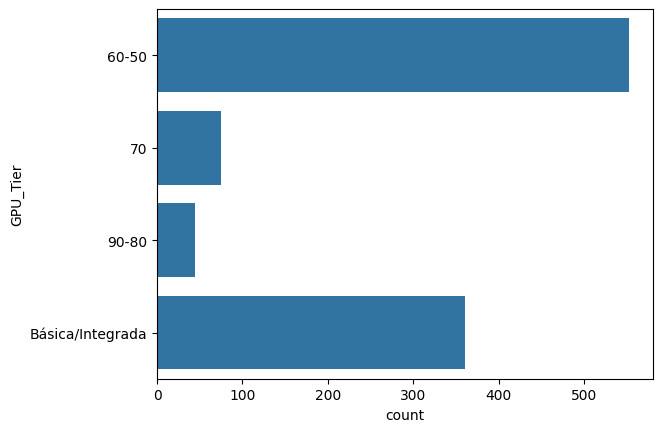

In [308]:
# Vamos a ver si es una serie potente (90, 80) o más modesta (60, 50)
df['GPU_Tier'] = 'Básica/Integrada'

# Si contiene números de gama alta
df.loc[df['Video graphics'].str.contains('90|80', na=False), 'GPU_Tier'] = '90-80' # Obsevraciones que contengan el valor 90 o 80 (| significa OR)
df.loc[df['Video graphics'].str.contains('70', na=False), 'GPU_Tier'] = '70'
df.loc[df['Video graphics'].str.contains('60|50', na=False), 'GPU_Tier'] = '60-50'

sns.countplot(df['GPU_Tier'])

La variable ``Display Resolution`` debería ser interesante pero tal como está no aporta mucha información. Vamos a calcular los pixeles totales ``Total_Pixels`` a partir de ``Display Resolution`` multiplicando el ancho por el largo.

In [309]:
df['Display Resolution'].head()

0      3840x2400
1      2560*1440
2      1920x1080
3    2560 x 1600
4    2560 x 1600
Name: Display Resolution, dtype: object

In [310]:
# Resolucion pantalla: Usamos un patrón que busca: número - algo en medio (x, *, X) - número
resolucion_split = df['Display Resolution'].str.extract(r'(\d+)\s*[xX*]\s*(\d+)')

# Creamos las columnas numéricas
df['Res_Width'] = resolucion_split[0].astype(float)
df['Res_Height'] = resolucion_split[1].astype(float)

# Calculamos el Total de Píxeles (MegaPíxeles)
# Esto es mucho más útil para el modelo que tener dos columnas separadas
df['Total_Pixels'] = (df['Res_Width'] * df['Res_Height']) / 1000000 # Divido entre 1M para simplificar la variable

# Tamaño pantalla: Buscamos el número que acompaña a "inch" o "inches"
df['Screen_Size'] = df['Display'].str.extract(r'(\d+[\.,]?\d*)').astype(float)
df['Screen_Size'].head()

0    18.0
1    15.6
2    15.6
3    16.0
4    16.0
Name: Screen_Size, dtype: float64

Las variables ``Webcam`` y ``Finger Print`` tienen mucho ruido tal como están, y es que me dan el tipo de webcam/huella. Dado que por lo general solo me ineterserá si tiene o no estas herramientas, voy a crear variables binarias 0|1 según el portatil tenga ``Webcam``, ``Finger Print``.

In [311]:
df[['Webcam', 'Finger Print']].head()

,Webcam,Finger Print
0,IR FHD type (30fps@1080p) with HDR 3D Noise Re...,NaN
1,HD Webcam (720p @ 30fps),NaN
2,NaN,NaN
3,NaN,NaN
4,"720p at 30 fps HD camera, Dual-array microphones",NaN


In [312]:
# Webcam ?
df['Has_Webcam'] = 0
# Si la columna original contiene texto descriptivo, asumimos que tiene webcam (ponemos un 1)
# Usamos .notna() para identificar las celdas que no están vacías
df.loc[df['Webcam'].notna(), 'Has_Webcam'] = 1

# Fingerprint ?
df['Has_Fingerprint'] = 0
# Si la columna original contiene texto descriptivo, asumimos que tiene huella (ponemos un 1)
# Usamos .notna() para identificar las celdas que no están vacías
df.loc[df['Finger Print'].notna(), 'Has_Fingerprint'] = 1

# Check
df[['Has_Webcam', 'Has_Fingerprint']].head()

,Has_Webcam,Has_Fingerprint
0,1,0
1,1,0
2,0,0
3,0,0
4,1,0


Vemos también que hay un montón de sistemas operativos diferentes, pero por lo general solo hay 3 de interés. Creamos por tanto la variable sistema operativo ``OS_Type`` tal que tome solo valores 'Other/Linux', 'Windows', 'macOS' o 'No OS' a partir de ``Operating System``.

In [313]:
df['Operating System'].head()

0    Windows® 11 Home
1    Windows® 11 Home
2    Windows® 11 Home
3     Windows 11 Home
4                 DOS
Name: Operating System, dtype: object

In [314]:
# Creamos una columna nueva simplificada
df['OS_Type'] = 'Other/Linux' # Valor por defecto

# Categorizamos mediante búsquedas de texto
# Buscamos cualquier versión de Windows
df.loc[df['Operating System'].str.contains('Windows', case=False, na=False), 'OS_Type'] = 'Windows'

# Buscamos ordenadores de Apple
df.loc[df['Operating System'].str.contains('Mac|macOS', case=False, na=False), 'OS_Type'] = 'macOS'

# Identificamos los que vienen sin sistema (DOS o No OS), que suelen ser más baratos
df.loc[df['Operating System'].str.contains('DOS|No OS|None', case=False, na=False), 'OS_Type'] = 'No OS'

# Check
df['OS_Type'].head()

0    Windows
1    Windows
2    Windows
3    Windows
4      No OS
Name: OS_Type, dtype: object

Antes de contiunar, para que el dataset esté lo más limpio posible, eliminamos todas las variables redundantes tras los cálculos anteriores. 

In [315]:
df.drop(['RAM', 'Weight', 'Display', 'Hard drive', 'Processor', 'Video graphics', 'Display Resolution', 'Res_Width', 'Res_Height', 'Operating System', 'Webcam', 'Display Refresh Rate', 'Warranty', 'Processor Generation', 'Finger Print', 'Video graphics Memorey', ], axis=1, inplace=True)
df.head()

,Brand,Price,RAM_GB,Weight_kg,Screen_Size,Video graphics Memory,Warranty_Years,Refresh Rate,Processor_Generation,Storage_GB,CPU_Class,GPU_Brand,GPU_Tier,Total_Pixels,Has_Webcam,Has_Fingerprint,OS_Type
0,MSI,320000,96.0,3.60,18.0,24.0,2.0,120.0,NaN,6144.0,Gama Alta (i9),Nvidia,60-50,9.2160,1,0,Windows
1,MSI,79999,16.0,2.40,15.6,8.0,2.0,165.0,14.0,1024.0,Gama Alta (i9),Nvidia,60-50,3.6864,1,0,Windows
2,Acer,39999,8.0,NaN,15.6,6.0,1.0,144.0,13.0,512.0,Gama Entrada (i3),Nvidia,60-50,2.0736,0,0,Windows
3,Dell,57999,16.0,2.49,16.0,8.0,1.0,120.0,NaN,512.0,Other,Nvidia,60-50,4.0960,0,0,Windows
4,Dell,89999,16.0,2.49,16.0,8.0,1.0,120.0,NaN,1024.0,Gama Alta (i9),Nvidia,60-50,4.0960,1,0,No OS


Convertimos a euros la variable ``Price``.

In [316]:
df['Price'] = df['Price'] * 0.018

# Limpieza de datos

In [317]:
df.head()

,Brand,Price,RAM_GB,Weight_kg,Screen_Size,Video graphics Memory,Warranty_Years,Refresh Rate,Processor_Generation,Storage_GB,CPU_Class,GPU_Brand,GPU_Tier,Total_Pixels,Has_Webcam,Has_Fingerprint,OS_Type
0,MSI,5760.000,96.0,3.60,18.0,24.0,2.0,120.0,NaN,6144.0,Gama Alta (i9),Nvidia,60-50,9.2160,1,0,Windows
1,MSI,1439.982,16.0,2.40,15.6,8.0,2.0,165.0,14.0,1024.0,Gama Alta (i9),Nvidia,60-50,3.6864,1,0,Windows
2,Acer,719.982,8.0,NaN,15.6,6.0,1.0,144.0,13.0,512.0,Gama Entrada (i3),Nvidia,60-50,2.0736,0,0,Windows
3,Dell,1043.982,16.0,2.49,16.0,8.0,1.0,120.0,NaN,512.0,Other,Nvidia,60-50,4.0960,0,0,Windows
4,Dell,1619.982,16.0,2.49,16.0,8.0,1.0,120.0,NaN,1024.0,Gama Alta (i9),Nvidia,60-50,4.0960,1,0,No OS


In [318]:
df.shape

(1033, 17)

In [319]:
df.isna().sum()

Brand                     56
Price                      0
RAM_GB                     0
Weight_kg                 40
Screen_Size                4
Video graphics Memory    358
Warranty_Years             2
Refresh Rate             353
Processor_Generation     337
Storage_GB                 2
CPU_Class                  0
GPU_Brand                  0
GPU_Tier                   0
Total_Pixels              21
Has_Webcam                 0
Has_Fingerprint            0
OS_Type                    0
dtype: int64

Voy a eliminar directamente las variables con muchos nulos. Podría hacer algo más fino como hemos visto, pero así le doy un chance a tu modelo a que sea mejor que el mío ;)

In [320]:
df.drop(['Refresh Rate', 'Processor_Generation', 'Video graphics Memory'], axis=1, inplace=True)

In [321]:
df.isna().sum()

Brand              56
Price               0
RAM_GB              0
Weight_kg          40
Screen_Size         4
Warranty_Years      2
Storage_GB          2
CPU_Class           0
GPU_Brand           0
GPU_Tier            0
Total_Pixels       21
Has_Webcam          0
Has_Fingerprint     0
OS_Type             0
dtype: int64

Todas las variables con nulos son numéricas excepto ``Brand``, vamos a ver cómo sería más razonable imputarlas.

In [322]:
# Seleccionar columnas numéricas del dataframe 
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numericas: ", num_cols)

Numericas:  ['Price', 'RAM_GB', 'Weight_kg', 'Screen_Size', 'Warranty_Years', 'Storage_GB', 'Total_Pixels', 'Has_Webcam', 'Has_Fingerprint']


Vemos que las variables binarias (categóricas) Python las ha construido como numéricas, así que vamos a cambiar el tipo de variable antes de continuar.

In [323]:
df[['Has_Webcam', 'Has_Fingerprint']] = df[['Has_Webcam', 'Has_Fingerprint']].astype(str)

In [324]:
# Seleccionar columnas numéricas del dataframe 
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numericas: ", num_cols)

Numericas:  ['Price', 'RAM_GB', 'Weight_kg', 'Screen_Size', 'Warranty_Years', 'Storage_GB', 'Total_Pixels']


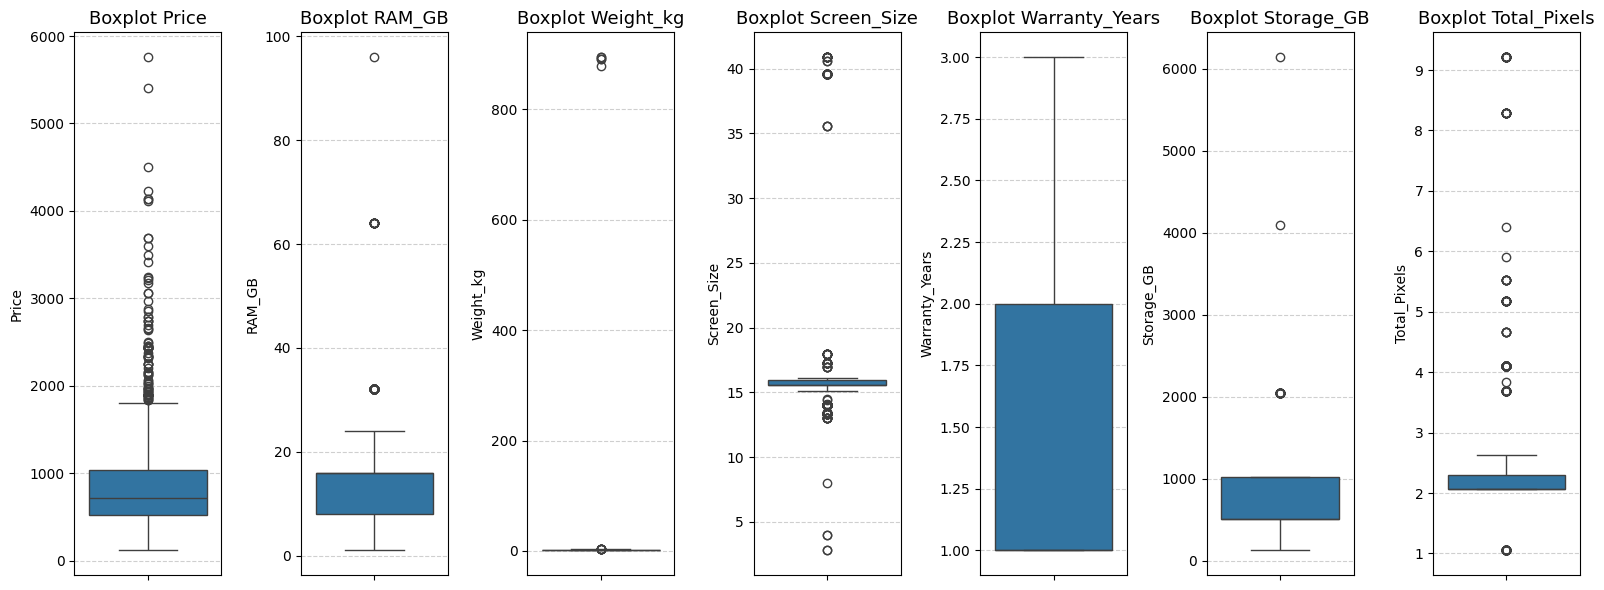

In [325]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de la figura (creamos una cuadrícula de subplots)
fig, axes = plt.subplots(ncols=7, nrows=1, figsize=(16, 6))
axes = axes.flatten()

# 3. Iteración para pintar cada boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df, 
        y=col, 
        ax=axes[i], 
        orient='v',
        legend=False      # Quita la leyenda repetitiva
    )
    axes[i].set_title(f'Boxplot {col}', fontsize=13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [326]:
df[df['Weight_kg'].isna()].head()

,Brand,Price,RAM_GB,Weight_kg,Screen_Size,Warranty_Years,Storage_GB,CPU_Class,GPU_Brand,GPU_Tier,Total_Pixels,Has_Webcam,Has_Fingerprint,OS_Type
2,Acer,719.982,8.0,NaN,15.6,1.0,512.0,Gama Entrada (i3),Nvidia,60-50,2.0736,0,0,Windows
62,HP,741.582,16.0,NaN,40.9,1.0,512.0,Gama Entrada (i3),Nvidia,60-50,2.0736,1,0,No OS
107,Dell,1679.994,32.0,NaN,16.0,3.0,1024.0,Other,Nvidia,60-50,4.0960,0,0,Windows
138,HP,539.982,8.0,NaN,39.6,1.0,1024.0,Gama Entrada (i3),Nvidia,60-50,2.0736,1,0,Windows
159,HP,741.582,16.0,NaN,40.9,1.0,512.0,Gama Entrada (i3),Nvidia,60-50,2.0736,1,0,No OS


Dado que no tengo más información y las variables con más nulos son las que he construido, así que las voy a imputar con la mediana en aras de no perder información ya que no tenemos muchas observaciones.

In [327]:
df['Weight_kg'].fillna(df['Weight_kg'].median(), inplace=True)
df['Screen_Size'].fillna(df['Screen_Size'].median(), inplace=True)
df['Storage_GB'].fillna(df['Storage_GB'].median(), inplace=True)
df['Total_Pixels'].fillna(df['Total_Pixels'].median(), inplace=True)
df['Warranty_Years'].fillna(df['Warranty_Years'].median(), inplace=True)

/var/folders/5b/g6h6206j3r13bvpzqq54lmf40000gn/T/ipykernel_4113/3465311425.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Weight_kg'].fillna(df['Weight_kg'].median(), inplace=True)
/var/folders/5b/g6h6206j3r13bvpzqq54lmf40000gn/T/ipykernel_4113/3465311425.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting

Vamos a explorar ahora los nulos en la variable ``Brand``.

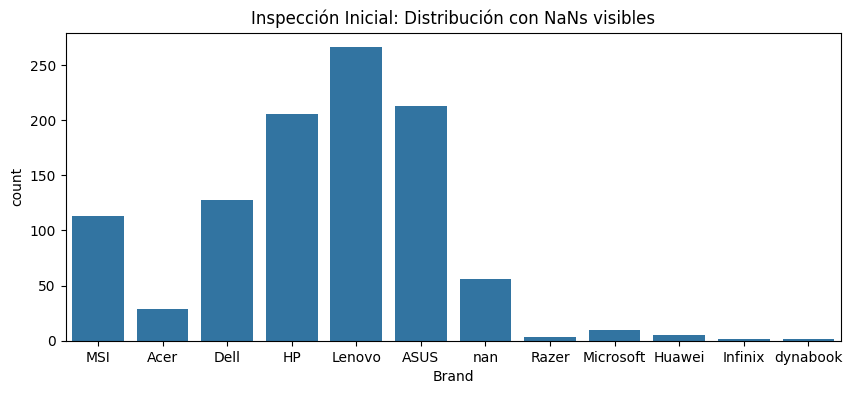

In [328]:
plt.figure(figsize=(10, 4))
# Convertimos la columna a string solo para el gráfico (asi puedo tener una barra con el nan)
sns.countplot(data=df.assign(Brand=df['Brand'].astype(str)), x='Brand')
plt.title('Inspección Inicial: Distribución con NaNs visibles')
plt.show()

Hay marcas que ni me suenan que agruparemos a continuación, así que por el momento simplemente vamos a imputar los nulos a la categoría "Unknown".

In [329]:
df['Brand'].fillna('Unknown', inplace=True)
df['Brand'].value_counts()

/var/folders/5b/g6h6206j3r13bvpzqq54lmf40000gn/T/ipykernel_4113/3821565983.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Brand'].fillna('Unknown', inplace=True)


Brand
Lenovo       266
ASUS         213
HP           206
Dell         128
MSI          113
Unknown       56
Acer          29
Microsoft     10
Huawei         5
Razer          3
Infinix        2
dynabook       2
Name: count, dtype: int64

# Análisis Exploratorio

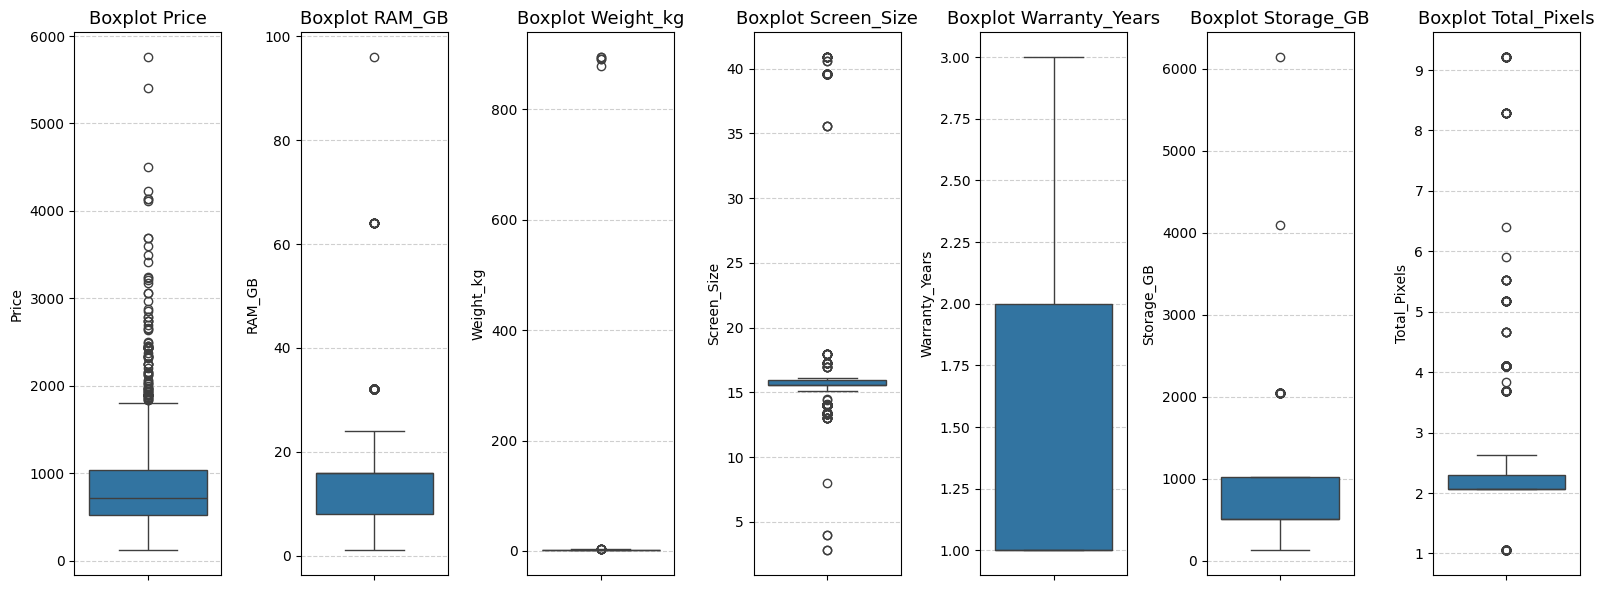

In [330]:
# Configuración de la figura (creamos una cuadrícula de subplots)
fig, axes = plt.subplots(ncols=7, nrows=1, figsize=(16, 6))
axes = axes.flatten()

# 3. Iteración para pintar cada boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df, 
        y=col, 
        ax=axes[i], 
        orient='v',
        legend=False      # Quita la leyenda repetitiva
    )
    axes[i].set_title(f'Boxplot {col}', fontsize=13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Lo primero que vemos es que la variable ``Weight_kg``tiene varios outliers muy exrtemos. Asumo que ha sido un error de tecleo o en la construcción así que vamos a dividir el peso entre 10 hasta que esté en un rango de Kg razonable (<10Kg).

In [331]:
df['Weight_kg'].describe()

count    1033.000000
mean        6.323611
std        61.675276
min         0.890000
25%         1.700000
50%         2.000000
75%         2.340000
max       895.000000
Name: Weight_kg, dtype: float64

In [332]:
# Definimos la lógica de división
def normalizar_peso(w):
    if w <= 0: return w # Evitar bucles infinitos con ceros
    while w >= 10:
        w = w / 10
    return w

# Aplicamos la función a la columna 'Weight_kg'
df['Weight_kg'] = df['Weight_kg'].apply(normalizar_peso)

# Verificamos los resultados
print("Resumen del peso tras la normalización:")
print(df['Weight_kg'].describe())

Resumen del peso tras la normalización:
count    1033.000000
mean        2.057890
std         0.652021
min         0.890000
25%         1.700000
50%         2.000000
75%         2.340000
max         8.950000
Name: Weight_kg, dtype: float64


A partir de la variable peso, se me ocurre construir una variable que mida el ratio pantalla/peso, de forma que me de una idea de lo grande que es la pantalla para el peso que tiene el portatil, y así poder distinguir entre portatiles más ligeros respecto a lo grandes que son.

In [333]:
df['Screen_Weight_Ratio'] = df['Screen_Size'] / df['Weight_kg']
print(df['Screen_Weight_Ratio'].describe())

count    1033.000000
mean        8.601564
std         3.316852
min         1.452514
25%         6.779661
50%         8.000000
75%         9.271523
max        25.797101
Name: Screen_Weight_Ratio, dtype: float64


De igual forma, cuanta RAM tiene respecto al peso que esto supone.

In [334]:
df['RAM_Weight_Ratio'] = df['RAM_GB'] / df['Weight_kg']
print(df['RAM_Weight_Ratio'].describe())

count    1033.000000
mean        6.939323
std         4.668100
min         0.400000
25%         4.419890
50%         6.400000
75%         8.247423
max        34.594595
Name: RAM_Weight_Ratio, dtype: float64


Voy a eliminar los outliers demasiado extremos para que no alteren mis modelos.

In [335]:
df = df[df['Weight_kg'] < 5]
df = df[df['Storage_GB'] < 2000]
df = df[df['RAM_GB'] < 40]

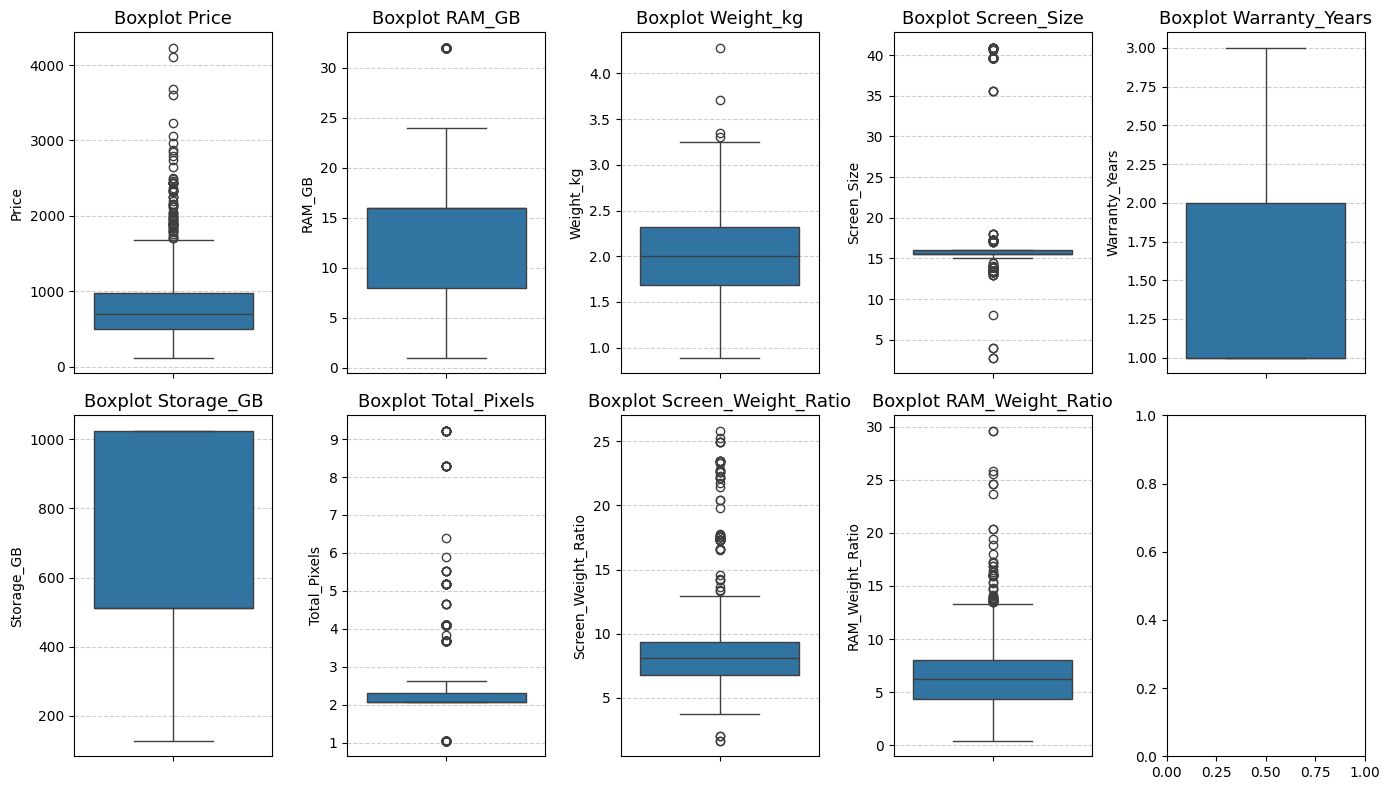

In [336]:
# Volvemos a crear la lista con las nuevas variables numericas
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Configuración de la figura (creamos una cuadrícula de subplots)
fig, axes = plt.subplots(ncols=5, nrows=2, figsize=(14, 8))
axes = axes.flatten()

# 3. Iteración para pintar cada boxplot
for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df, 
        y=col, 
        ax=axes[i], 
        orient='v',
        legend=False      # Quita la leyenda repetitiva
    )
    axes[i].set_title(f'Boxplot {col}', fontsize=13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Sigo teniendo algún atípico pero todo parece razonable, vamos a continuar con el análisis exploratorio.

Comenzamos viendo la matriz de correlaciones.

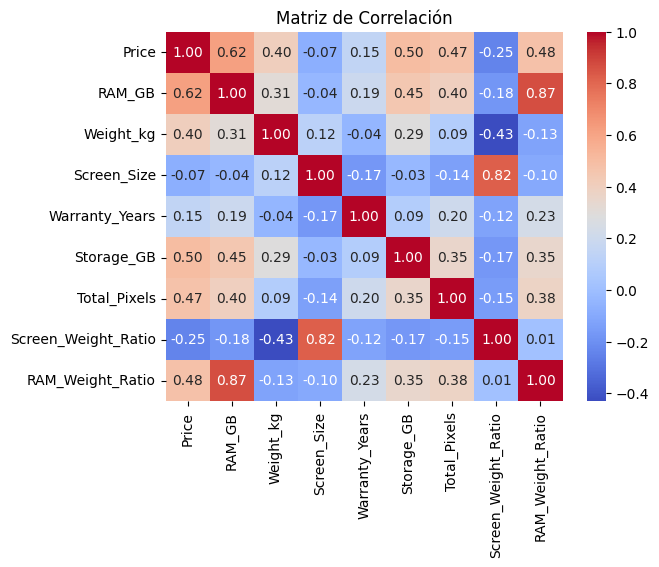

In [337]:
# MATRIZ DE CORRELACIÓN (Heatmap)
# Queremos ver qué variables tienen una relación lineal fuerte con 'Price'

# Seleccionamos solo las numéricas para la correlación
correlation_matrix = df[num_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación")
plt.show()

Vemos que las variables ratio con el peso están muy correladas con la original, así que puede ser recomendable no considerarlas. Vemos que la variable ``RAM_GB`` tiene una correlación positiva fuertre con el precio, es decir, esperaremos que a mayor RAM el precio suba (lo cual era previsible a priori). También con el ``Storage_GB`` y ``Total_Pixels``.

También vemos como el peso disminuye el precio.

Vamos a comprobar estas relaciones con más detalle.

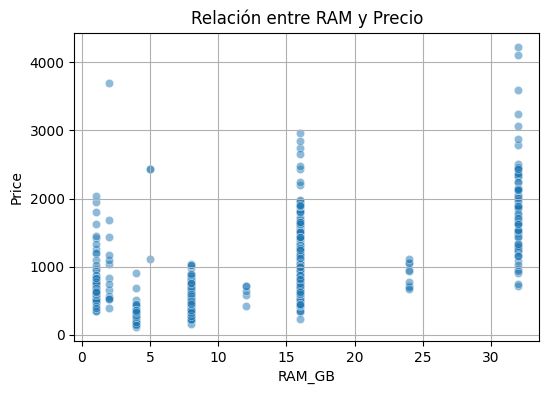

In [338]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='RAM_GB', y='Price', alpha=0.5)
plt.title("Relación entre RAM y Precio")
plt.grid(True)
plt.show()

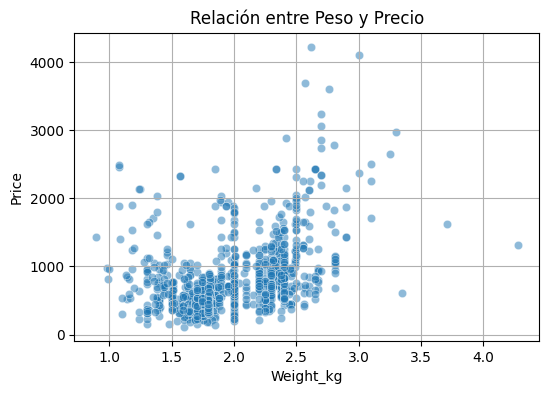

In [339]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Weight_kg', y='Price', alpha=0.5)
plt.title("Relación entre Peso y Precio")
plt.grid(True)
plt.show()

Vamos ahora a examinar las variables categóricas.

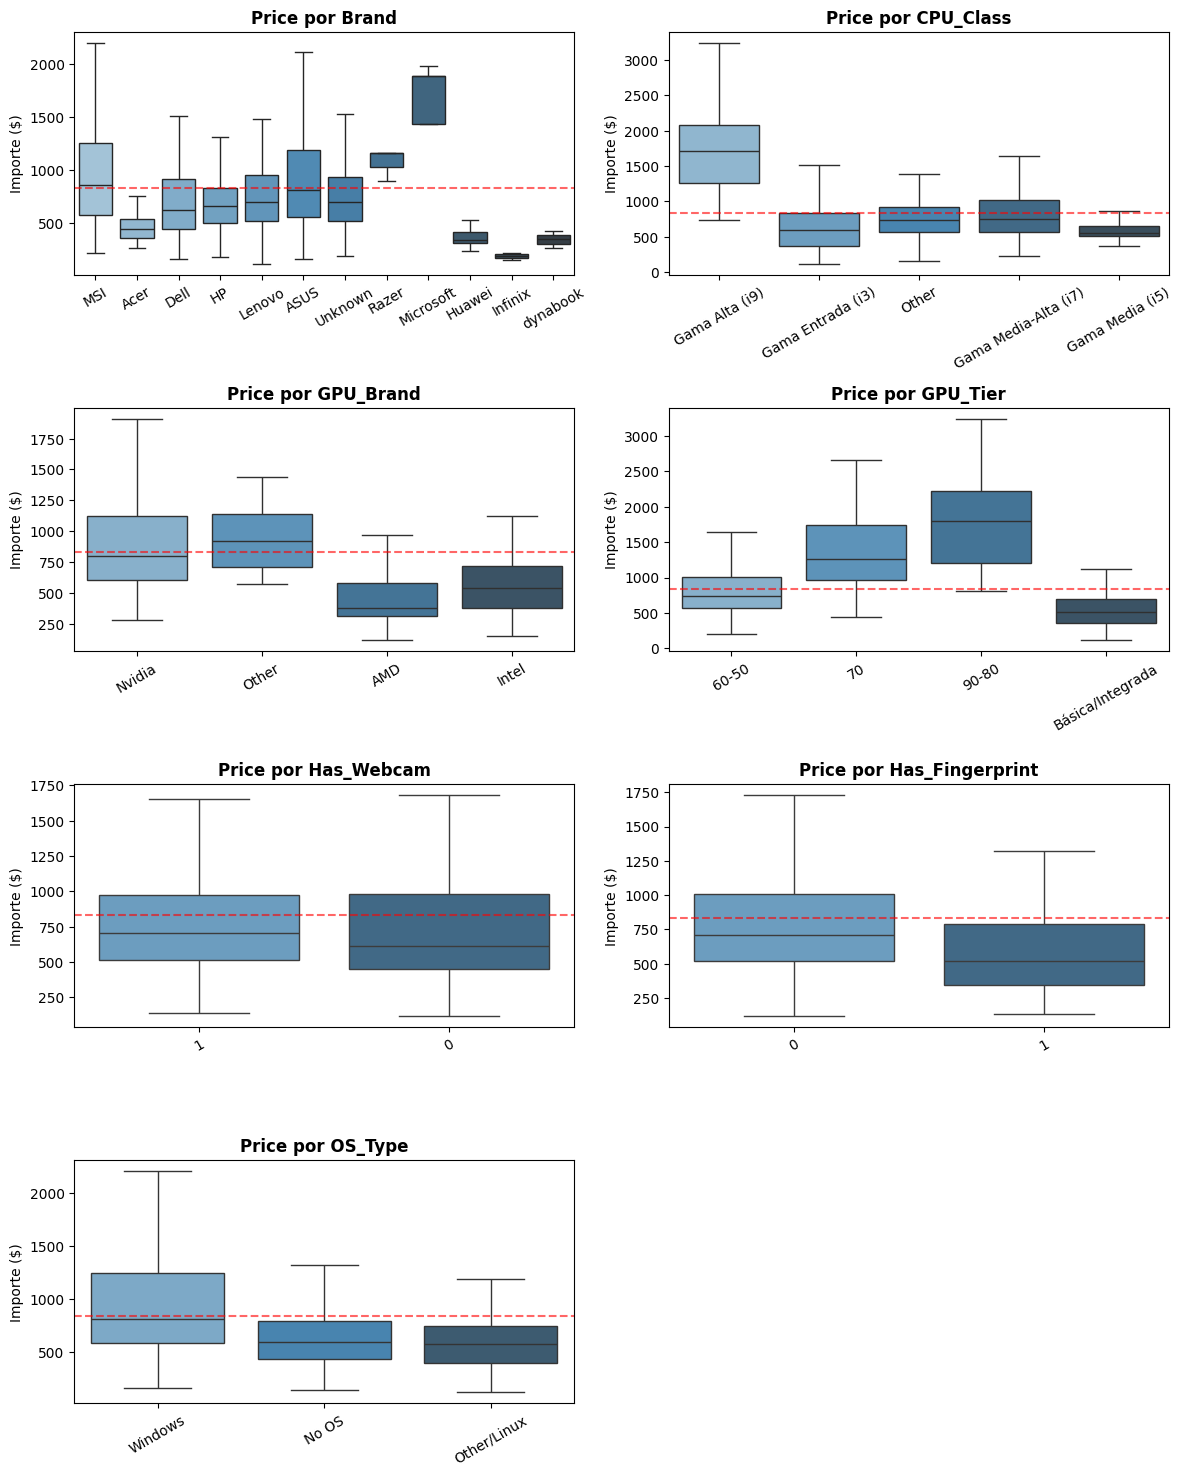

In [340]:
# Definimos nuestras variables
target_reg = 'Price' # Nuestra variable continua
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Configuramos la cuadrícula 5x2 (ajustar según número de variables)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 18))
axes = axes.flatten()

for i, var in enumerate(cat_cols):
    if i < len(axes):
        # Creamos un boxplot para ver distribución, mediana y outliers
        sns.boxplot(
            data=df, 
            x=var, 
            y=target_reg, 
            ax=axes[i], 
            palette='Blues_d',
            hue = var,
            showfliers=False # Opcional: ocultar outliers para ver mejor la caja
        )
        
        # Añadimos una línea horizontal con la media global para comparar
        media_global = df[target_reg].mean()
        axes[i].axhline(media_global, color='red', linestyle='--', alpha=0.6, label='Media Global')
        
        axes[i].set_title(f'{target_reg} por {var}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Importe ($)')
        axes[i].tick_params(axis='x', rotation=30)

# Limpieza de espacios vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Vemos como la variable CPU tiene el comportamiento que cabría esperar, así como ``GPU_Tier``o ``GPU_Brand``. 

La única que puede merecer la pena agrupar es ``Brand``, pero ya que vemos marcas con precios medios muy altos y bajos la vamos a dejar así.

# Entrenamiento de Modelos

In [341]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np
from sklearn.preprocessing import StandardScaler

Comenzamos como siempre definiendo la matriz con las variables predictoras y mi variable respuesta (``Price``).

In [342]:
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

A continuación terminamos de formatear el dataframe construyendo las variables dummy y escalando las variables numéricas.

In [343]:
# Crear dummies
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# drop_first=True elimina la primera columna para evitar la trampa de multicolinealidad
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

# Alineamos las columnas del Train/Test
X_test = X_test.reindex(columns = X_train.columns, fill_value=0)

# Mostrar columnas relacionadas con 'Brand' por ejemplo
X_train.filter(like='Brand').head()

,Brand_Acer,Brand_Dell,Brand_HP,Brand_Huawei,Brand_Infinix,Brand_Lenovo,Brand_MSI,Brand_Microsoft,Brand_Razer,Brand_Unknown,Brand_dynabook,GPU_Brand_Intel,GPU_Brand_Nvidia,GPU_Brand_Other
890,False,False,True,False,False,False,False,False,False,False,False,True,False,False
785,False,False,False,False,False,False,False,False,False,False,False,True,False,False
343,False,False,False,False,False,False,False,False,False,False,False,False,True,False
827,False,False,False,False,False,False,False,False,False,False,True,True,False,False
965,False,True,False,False,False,False,False,False,False,False,False,True,False,False


In [344]:
# Escalamos variables numericas
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Definicion del scaler
scaler = StandardScaler()

# Ajustamos (fit) SOLO con el train y transformamos ambos
# Esto evita que el modelo sepa de antemano el rango total de los datos de prueba
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [345]:
X_train.head()

,RAM_GB,Weight_kg,Screen_Size,Warranty_Years,Storage_GB,Total_Pixels,Screen_Weight_Ratio,RAM_Weight_Ratio,Brand_Acer,Brand_Dell,Brand_HP,Brand_Huawei,Brand_Infinix,Brand_Lenovo,Brand_MSI,Brand_Microsoft,Brand_Razer,Brand_Unknown,Brand_dynabook,CPU_Class_Gama Entrada (i3),CPU_Class_Gama Media (i5),CPU_Class_Gama Media-Alta (i7),CPU_Class_Other,GPU_Brand_Intel,GPU_Brand_Nvidia,GPU_Brand_Other,GPU_Tier_70,GPU_Tier_90-80,GPU_Tier_Básica/Integrada,Has_Webcam_1,Has_Fingerprint_1,OS_Type_Other/Linux,OS_Type_Windows
890,0.444537,-0.597851,3.818941,-0.606063,-0.572199,-0.155665,4.166531,0.694087,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,True,False,False,False
785,-0.618528,-0.692914,-0.214841,-0.606063,-0.572199,-0.345949,0.104847,-0.448743,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True,True,False,False,True
343,0.444537,-0.217602,-0.214841,1.371467,1.346634,0.986036,-0.172288,0.496973,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,True
827,-0.618528,-0.550320,-0.214841,-0.606063,-0.572199,-0.345949,0.015093,-0.489580,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True,True,False,False,False
965,-0.618528,-1.524709,-0.585949,-0.606063,-1.531615,-0.345949,0.298618,-0.138174,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True


Entrenamos los modelos básicos con un bucle. Al final siempre se entrenan instanciando el modelo y llamando ``.fit()`` y ``.predict()``

In [346]:
# Definimos la lista de modelos a testear en un diccionario
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Árbol de Decisión": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100),
    "XGBoost": XGBRegressor(random_state=42)
}

# Diccionario para guardar los resultados de cada modelo
resultados = []

# Bucle de entrenamiento y evaluación
for nombre, modelo in modelos.items():
    # Entrenar
    modelo.fit(X_train, y_train)
    
    # Predecir
    preds = modelo.predict(X_test)
    
    # Calcular Métricas
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    # Guardar en la lista
    resultados.append({
        "Modelo": nombre,
        "MAE (€)": mae,
        "RMSE (€)": rmse,
        "R2 Score": r2
    })

# Convertir resultados a DataFrame para visualizar mejor
df_resultados = pd.DataFrame(resultados).sort_values(by="MAE (€)")

Veamos el resultado con cada modelo (entrenado con los hiperparámetros por defecto).

Como cabía esperar, los que mejores predicciones obtienen son los de Random Forest/Boosting. 

In [347]:
df_resultados

,Modelo,MAE (€),RMSE (€),R2 Score
2,Random Forest,180.897635,282.705306,0.730706
3,XGBoost,183.160645,296.708649,0.703367
1,Árbol de Decisión,209.559732,366.385273,0.547692
0,Regresión Lineal,221.479962,320.278938,0.654367


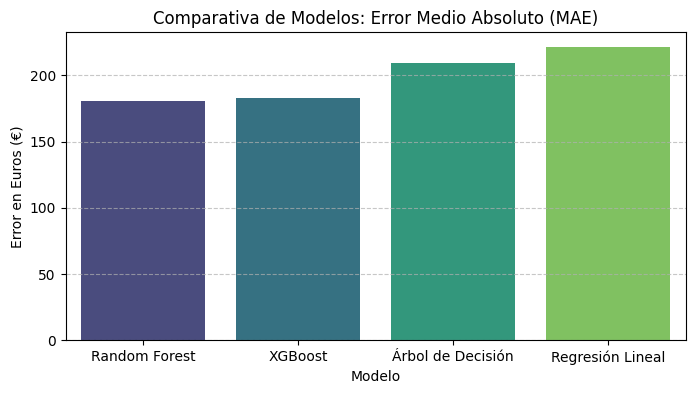

In [348]:
# Representación Gráfica
plt.figure(figsize=(8, 4))
sns.barplot(data=df_resultados, x="Modelo", y="MAE (€)", palette="viridis", hue = "Modelo")
plt.title("Comparativa de Modelos: Error Medio Absoluto (MAE)")
plt.ylabel("Error en Euros (€)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Para terminar, ya que XGBoost suele ser el que mejor funciona, vamos a intentar ajustar un mjoer modelo de XGBoost optimizando el error sobre un grid de distintos hiperparámetros.

In [349]:
from sklearn.model_selection import GridSearchCV

# 1. Definimos el modelo base
xgb_base = XGBRegressor(random_state=42, n_jobs=-1)

# 2. Definimos la malla de parámetros (Grid)
# Nota: Empieza con pocos valores para que no tarde demasiado
param_grid = {
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 500, 1000],
    'subsample': [0.8, 1.0]
}

# 3. Configuramos el GridSearchCV
# scoring='neg_mean_absolute_error': queremos minimizar el error
# cv=3: validación cruzada de 3 carpetas para ahorrar tiempo
grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=0
)

# 4. Ajustamos el modelo (este paso puede llevar varios minutos)
grid_xgb.fit(X_train, y_train)

# 5. Mejores resultados
print("Mejores parámetros encontrados:")
print(grid_xgb.best_params_)

# 6. Modelo final optimizado
best_xgb = grid_xgb.best_estimator_

Mejores parámetros encontrados:
{'learning_rate': 0.01, 'max_depth': 6, 'n_estimators': 1000, 'subsample': 0.8}


In [350]:
from sklearn import metrics

# Predicciones con el mejor modelo
best_preds = best_xgb.predict(X_test)

# Métricas finales
print('--- XGBOOST OPTIMIZADO ---')
print('MAE:', metrics.mean_absolute_error(y_test, best_preds))
print('R2 Score:', metrics.r2_score(y_test, best_preds))

--- XGBOOST OPTIMIZADO ---
MAE: 175.30764325647544
R2 Score: 0.7300269878453158


El error se reduce como cabía esperar, así que nos quedamos con este modelo.

Vamos a ver las predicciones de mi modelo final. 

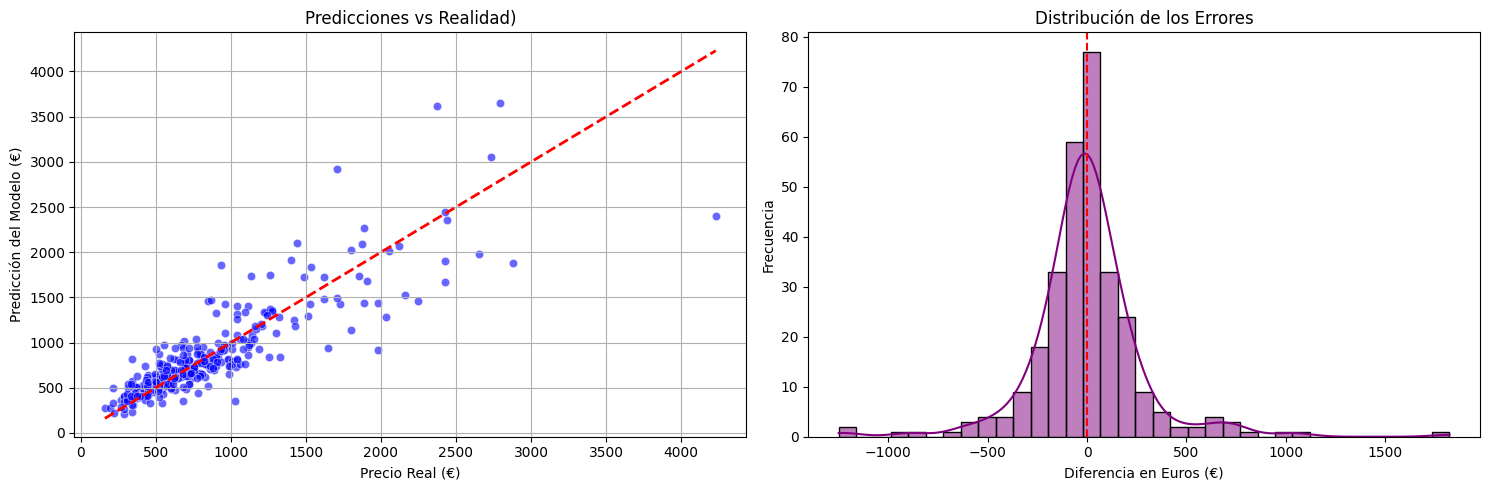

In [351]:
# Calculamos los residuos (Error real = Valor Real - Predicción)
residuos = y_test - best_preds

plt.figure(figsize=(15, 5))

# GRÁFICO 1: Valor Real vs. Predicción
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=best_preds, alpha=0.6, color='blue')
# Dibujamos la línea de "Predicción Perfecta" (y = x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.title(f"Predicciones vs Realidad)")
plt.xlabel("Precio Real (€)")
plt.ylabel("Predicción del Modelo (€)")
plt.grid(True)

# GRÁFICO 2: Histograma de los Errores (Residuos)
plt.subplot(1, 2, 2)
sns.histplot(residuos, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--') # Línea de error cero
plt.title("Distribución de los Errores")
plt.xlabel("Diferencia en Euros (€)")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

El modelo final seleccionado es un modelo de XGBoost por las buenas predicciones que obtenemos con el modelo entrenado. Podemos ver que en la muestra de test las métricas obtenidas son las que se indican debajo. 

In [352]:
print('MAE (Error Medio Absoluto):', metrics.mean_absolute_error(y_test, best_preds))
print('MSE (Error Cuadrático Medio):', metrics.mean_squared_error(y_test, best_preds))
print('RMSE (Raíz del Error Cuadrático Medio):', np.sqrt(metrics.mean_squared_error(y_test, best_preds)))
print('R2 Score (Varianza explicada):', metrics.r2_score(y_test, best_preds))

MAE (Error Medio Absoluto): 175.30764325647544
MSE (Error Cuadrático Medio): 80123.83861363136
RMSE (Raíz del Error Cuadrático Medio): 283.0615456285635
R2 Score (Varianza explicada): 0.7300269878453158


Espero que hayas podido llegar a un modelo tan bueno como este e incluso mejor. Podrías haber hecho una limpieza de variables distintas, construir más variables, utilizar más modelos o más hiperparámetros... Las posibilidades son infinitas ahora que dominas Python y el ML, así que espero tu mensaje diciendo que has obtenido un error más bajo al mío ;)

Y por supuesto, enhorabuena, después de llegar hasta aquí ya has aprendido todo lo que necesitas para ser Data Scientist. 

Lo comprobaremos en el último modulo práctico. 